# LangGraph + Groq Joke Agent

This notebook builds a tiny LangGraph workflow that asks a Groq-hosted chat model to tell a short, clean joke.

## 1. Sync project dependencies

This repo uses `uv` for dependencies. Run the cell below to sync the project, then use the `.venv` Python environment as your notebook kernel.

In [24]:
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

assert (project_root / "pyproject.toml").exists(), "Run this notebook from the project root or notebooks folder."

!UV_CACHE_DIR="{project_root / '.uv-cache'}" uv sync --project "{project_root}"

print(f"Project environment: {project_root / '.venv'}")
print("If imports fail, switch this notebook to the .venv kernel and rerun the cells.")

Resolved 73 packages in 19ms
Checked 68 packages in 9ms
Project environment: /Users/aman/Work/ai/guide/.venv
If imports fail, switch this notebook to the .venv kernel and rerun the cells.


## 2. Configure the Groq API key

The key is read from `GROQ_API_KEY` if it is already set. Otherwise, the notebook prompts for it securely.

In [25]:
import getpass
import os

if not os.environ.get("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

## 3. Build a one-node LangGraph workflow

The graph state stores the joke topic and structured joke fields. The single `tell_joke` node calls Groq through LangChain structured output.

In [26]:
from typing import TypedDict

from langchain_groq import ChatGroq
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field


class Joke(BaseModel):
    setup: str = Field(description="The setup of the joke")
    punchline: str = Field(description="The punchline of the joke")
    rating: int = Field(description="How funny the joke is from 1 to 10")


class JokeState(TypedDict):
    topic: str
    setup: str
    punchline: str
    rating: int


# MODEL = "llama-3.3-70b-versatile"
MODEL = "openai/gpt-oss-120b"
llm = ChatGroq(model=MODEL, temperature=0.8)
structured_llm = llm.with_structured_output(Joke)



def tell_joke(state: JokeState) -> JokeState:
    prompt = f"Tell me a short, clean joke about {state['topic']}."
    joke = structured_llm.invoke(prompt)
    return {
        "topic": state["topic"],
        "setup": joke.setup,
        "punchline": joke.punchline,
        "rating": joke.rating,
    }


builder = StateGraph(JokeState)
builder.add_node("tell_joke", tell_joke)
builder.add_edge(START, "tell_joke")
builder.add_edge("tell_joke", END)

joke_agent = builder.compile()

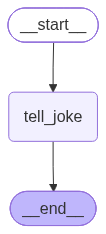

In [27]:
from IPython.display import Image, display
display(Image(joke_agent.get_graph().draw_mermaid_png()))

## 4. Run the joke agent

Change the `topic` value to get a joke about something else.

In [29]:
result = joke_agent.invoke({"topic": "programming", "setup": "", "punchline": "", "rating": 0})

# print(f"Setup: {result['setup']}")
# print(f"Punchline: {result['punchline']}")
# print(f"Rating: {result['rating']}/10")

In [30]:
print(f"Setup: {result['setup']}")
print(f"Punchline: {result['punchline']}")
print(f"Rating: {result['rating']}/10")

Setup: Why do programmers prefer dark mode?
Punchline: Because light attracts bugs!
Rating: 8/10


In [36]:
result = joke_agent.invoke({"topic": "cricket", "setup": "", "punchline": "", "rating": 0})

print(f"Setup: {result['setup']}")
print(f"Punchline: {result['punchline']}")
print(f"Rating: {result['rating']}/10")

Setup: Why did the cricket team bring a ladder to the match?
Punchline: Because they heard the wickets were high!
Rating: 7/10
